<a href="https://colab.research.google.com/github/DanielYaari28/AIPI510P1/blob/daniel-feature-engineering/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/DanielYaari28/AIPI510P1/refs/heads/daniel-feature-engineering/data/cleaned_college_data.csv"

df = pd.read_csv(url)

In [2]:
df.shape

(807, 15)

In [3]:
df.columns

Index(['UNITID', 'INSTNM', 'STABBR', 'CONTROL', 'UGDS', 'C150_4', 'RET_FT4',
       'NPT4_PUB', 'NPT4_PRIV', 'DEBT_MDN', 'COSTT4_A', 'MD_EARN_WNE_P10',
       'PCTPELL', 'ADM_RATE', 'NET_PRICE'],
      dtype='object')

In [4]:
#Cat 1: Student Success
df["STUDENT_SUCCESS"] = df["RET_FT4"] * 0.3 + df["C150_4"] * 0.7

In [5]:
df.sort_values("STUDENT_SUCCESS", ascending=False)

,UNITID,INSTNM,STABBR,CONTROL,UGDS,C150_4,RET_FT4,NPT4_PUB,NPT4_PRIV,DEBT_MDN,COSTT4_A,MD_EARN_WNE_P10,PCTPELL,ADM_RATE,NET_PRICE,STUDENT_SUCCESS
393,186131,Princeton University,NJ,2,5709.0,0.9761,0.9835,NaN,6128.0,10000.0,84040.0,110066.0,0.1924,0.0462,6128.0,0.97832
286,166027,Harvard University,MA,2,7601.0,0.9758,0.9830,NaN,19066.0,12500.0,85540.0,101817.0,0.1643,0.0365,19066.0,0.97796
577,215062,University of Pennsylvania,PA,2,10650.0,0.9654,0.9888,NaN,28699.0,14000.0,89028.0,111371.0,0.1653,0.0540,28699.0,0.97242
292,166683,Massachusetts Institute of Technology,MA,2,4535.0,0.9641,0.9908,NaN,20111.0,12462.0,82730.0,143372.0,0.1932,0.0455,20111.0,0.97211
481,198419,Duke University,NC,2,6442.0,0.9678,0.9793,NaN,29612.0,12000.0,87072.0,97800.0,0.1403,0.0571,29612.0,0.97125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,154022,The University of Arizona Global Campus,AZ,1,20152.0,0.1068,0.3473,NaN,31266.0,9500.0,37594.0,35404.0,0.3207,NaN,31266.0,0.17895
779,445027,American InterContinental University System,AZ,3,7111.0,0.0851,0.3596,NaN,15172.0,9500.0,22256.0,36144.0,0.7100,NaN,15172.0,0.16745
781,445267,Central Methodist University-College of Gradua...,MO,2,2092.0,0.0000,0.5294,NaN,14601.0,13292.0,22310.0,48991.0,0.3188,0.8753,14601.0,0.15882
792,460349,Johnson & Wales University-Online,RI,2,2202.0,0.0000,0.5217,NaN,20252.0,16334.0,26864.0,43418.0,0.3623,0.9097,20252.0,0.15651


In [7]:
student_success = (
    df
    .sort_values("STUDENT_SUCCESS", ascending=False)
    .head(10)
    [["INSTNM", "C150_4", "RET_FT4", "STUDENT_SUCCESS"]]
)

student_success

,INSTNM,C150_4,RET_FT4,STUDENT_SUCCESS
393,Princeton University,0.9761,0.9835,0.97832
286,Harvard University,0.9758,0.9830,0.97796
577,University of Pennsylvania,0.9654,0.9888,0.97242
292,Massachusetts Institute of Technology,0.9641,0.9908,0.97211
481,Duke University,0.9678,0.9793,0.97125
172,University of Chicago,0.9585,0.9926,0.96873
414,Columbia University in the City of New York,0.9610,0.9800,0.96670
101,Yale University,0.9574,0.9878,0.96652
592,Brown University,0.9569,0.9882,0.96629
380,Dartmouth College,0.9554,0.9842,0.96404


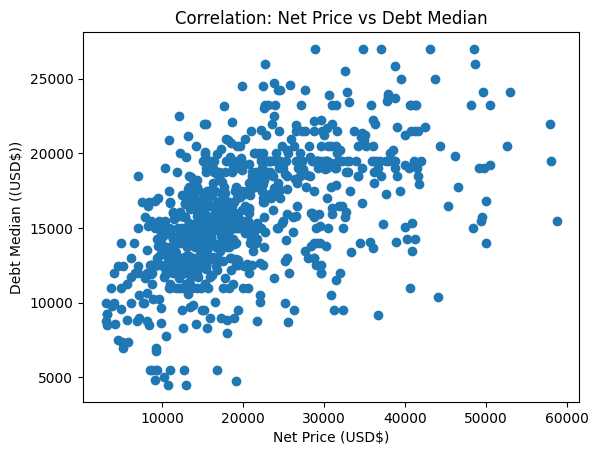

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["NET_PRICE"], df["DEBT_MDN"])
plt.xlabel("Net Price (USD$)")
plt.ylabel("Debt Median (USD$)")
plt.title("Correlation: Net Price vs Debt Median")
plt.show()

In [11]:
r = df["NET_PRICE"].corr(df["DEBT_MDN"])
print(r)

0.5578354517886546


R^2=0.5582=0.31

About 31% of the variation is associated with their linear relationship.
They're related, but they're not measuring the exact same thing.